In [46]:
#Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Importing modules from sklearn library
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score

#Importing harmless warnings
import warnings
warnings.filterwarnings('ignore')

In [47]:
#Data sample
data = pd.read_csv('diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [48]:
#Data volume
data.shape

(768, 9)

In [49]:
#Data quality check
pd.DataFrame({'Missing Values' : round(data.isnull().mean()*100, 2), 'Data Types' : data.dtypes})

,Missing Values,Data Types
Pregnancies,0.0,int64
Glucose,0.0,int64
BloodPressure,0.0,int64
SkinThickness,0.0,int64
Insulin,0.0,int64
BMI,0.0,float64
DiabetesPedigreeFunction,0.0,float64
Age,0.0,int64
Outcome,0.0,int64


In [50]:
#Data duplicate check in row
if len(data[data.duplicated()]) > 0:
    print('Row has duplicates')
else:
    print('Row has no duplicates')    

Row has no duplicates


In [51]:
#Data duplicate check in column
has_duplicates = data.shape[1] != data.T.drop_duplicates().T.shape[1]
if has_duplicates == True:
    print('Column has duplicates')
elif has_duplicates == False:
    print('Column has no duplicates')

Column has no duplicates


In [52]:
#Proportion of the target columns
data['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [53]:
#Preparing the data for ML model

#Dependency split
x = data.iloc[:, : -1]
y = data[['Outcome']]

#Train test split
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state = 42, test_size = 0.2)

#Dimension of train test columns after split
print(f'Dimensions of Train & Test columns after splitting:')
print(f'\nDimensions of Train columns {x_train.shape}, {y_train.shape}')
print(f'Dimensions of Test columns {x_test.shape}, {y_test.shape}')

Dimensions of Train & Test columns after splitting:

Dimensions of Train columns (614, 8), (614, 1)
Dimensions of Test columns (154, 8), (154, 1)


In [54]:
#logistic regression model
logreg_model = LogisticRegression(random_state=42)
logreg_model.fit(x_train, y_train)
print('Training Accuracy:', round(logreg_model.score(x_train, y_train)*100, 2), '%')

Training Accuracy: 77.2 %


Classification Reoprt: 

               precision    recall  f1-score   support

           0       0.79      0.81      0.80        96
           1       0.67      0.64      0.65        58

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.74      0.75      0.75       154



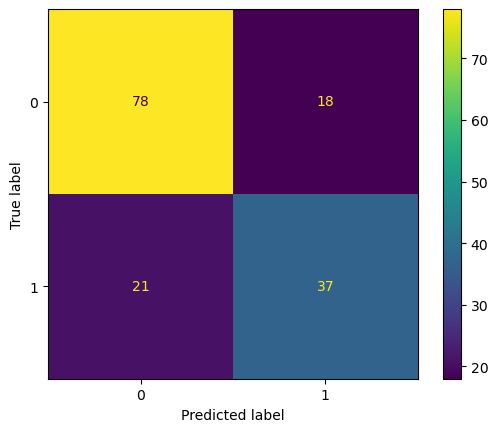

In [55]:
#Model testing
y_pred = logreg_model.predict(x_test)

#Model metrics
print('Classification Reoprt: \n\n', classification_report(y_pred, y_test))
cm = ConfusionMatrixDisplay.from_predictions(y_pred, y_test)

In [56]:
#Testing score
print('Testing Score:', round(accuracy_score(y_test, y_pred)*100,2), '%')

Testing Score: 74.68 %


# Oversampling to balance the dataset

In [57]:
#Import oversampling
from imblearn.over_sampling import SMOTE

#Resample
smote = SMOTE(random_state = 42)

#Do sampling only for the training data
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [58]:
#Data distribution before smote
round(y_train.value_counts(normalize = True)*100, 2)

Outcome
0          65.31
1          34.69
Name: proportion, dtype: float64

In [59]:
#Data distribution after smote
round(y_train_smote.value_counts(normalize = True)*100, 2)

Outcome
0          50.0
1          50.0
Name: proportion, dtype: float64

In [60]:
#logistic regression model
log_regmodel_sm = LogisticRegression(random_state = 42)
log_regmodel_sm.fit(x_train_smote, y_train_smote)
print('Training Score:', round(log_regmodel_sm.score(x_train_smote, y_train_smote)*100, 2), '%')

Training Score: 75.81 %


Classification Report: 

               precision    recall  f1-score   support

           0       0.83      0.69      0.75        99
           1       0.57      0.75      0.65        55

    accuracy                           0.71       154
   macro avg       0.70      0.72      0.70       154
weighted avg       0.74      0.71      0.71       154



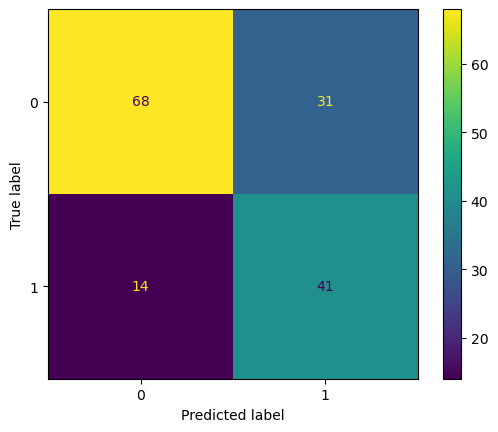

In [61]:
#Model testing
y_pred_sm = log_regmodel_sm.predict(x_test)

#Model metrics
print('Classification Report: \n\n', classification_report(y_test, y_pred_sm))
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_sm)

In [62]:
#Testing score
print('Testing Score:', round(accuracy_score(y_test, y_pred_sm)*100,2), '%')

Testing Score: 70.78 %


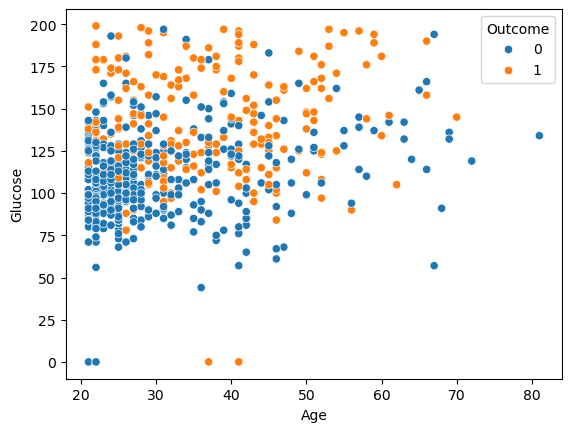

In [63]:
#Scatter plot for age vs glucose in raw train data with target as hue
sns.scatterplot(x=x_train['Age'],
                y=x_train['Glucose'],
                hue=y_train.iloc[:, 0])  # Select the first column to get a 1D Series
plt.show()

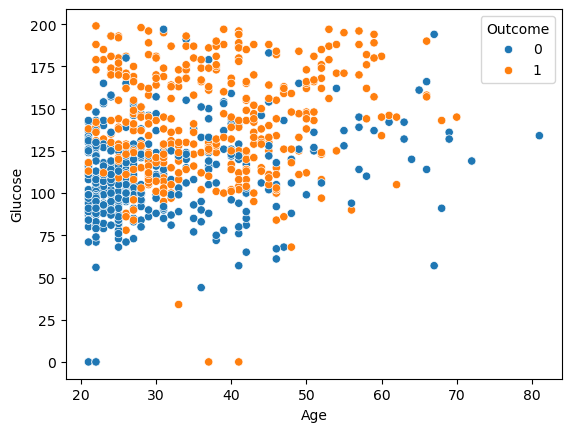

In [64]:
#Scatter plot for age vs glucose in smote train data with target as hue
sns.scatterplot(x=x_train_smote['Age'],
                y=x_train_smote['Glucose'],
                hue=y_train_smote.iloc[:, 0])  # Select the first column to get a 1D Series
plt.show()

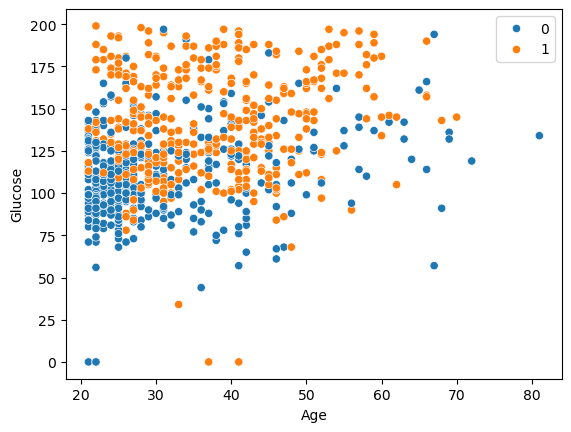

In [79]:
ax = sns.scatterplot(x=x_train_smote['Age'],
            y=x_train_smote['Glucose'],
            hue=y_train_smote.values.ravel())  # Convert DataFrame to NumPy array first
plt.show()